In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [54]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [55]:
df.info()

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary\n")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows: 0

Statistical Summary



,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [56]:
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Shape After Removing Duplicates: (200, 5)


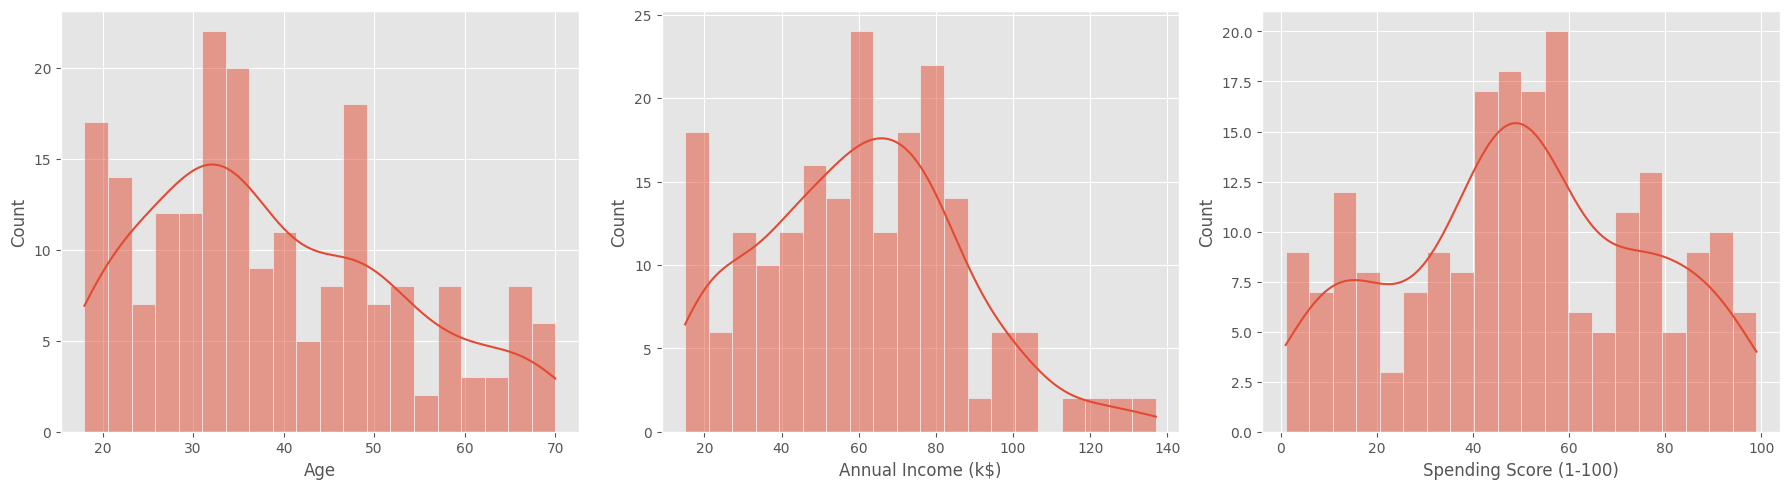

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0])

sns.histplot(df["Annual Income (k$)"], bins=20, kde=True, ax=axes[1])

sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True, ax=axes[2])

plt.tight_layout()
plt.show()

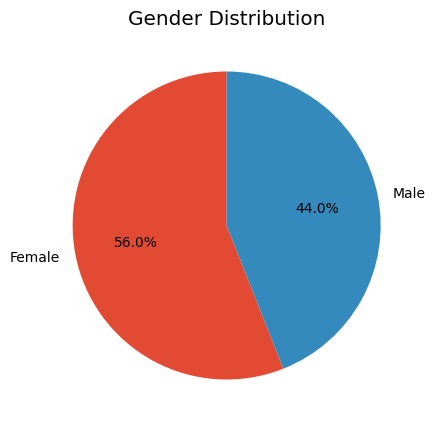

In [58]:
plt.figure(figsize=(5,5))

df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

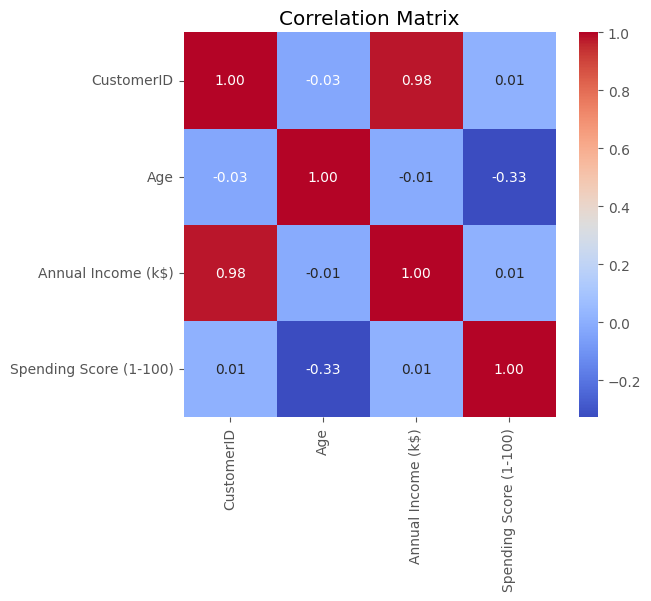

In [59]:
plt.figure(figsize=(6,5))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

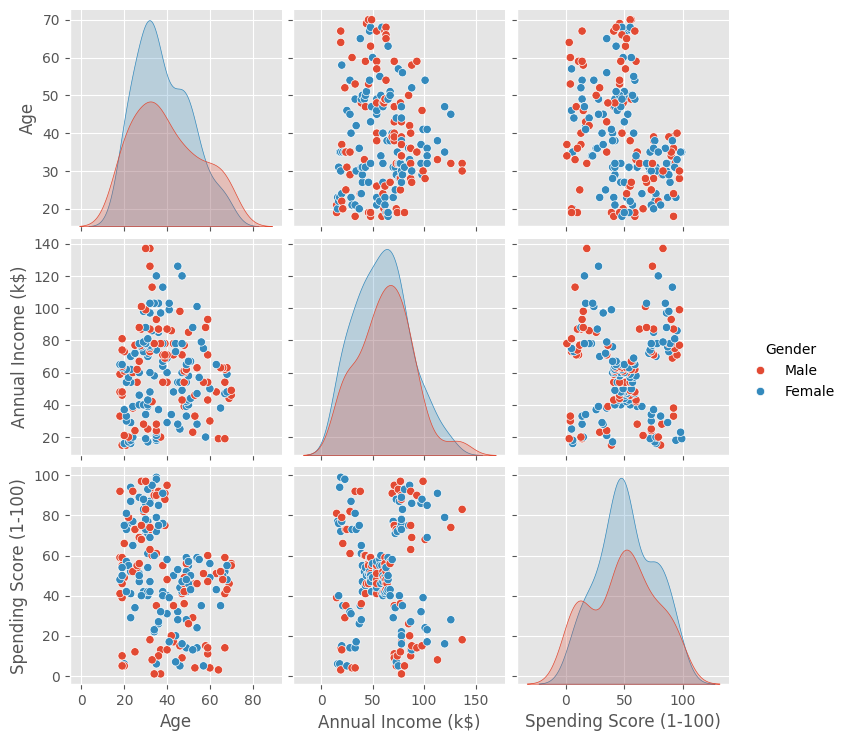

In [60]:
sns.pairplot(
    df,
    vars=["Age","Annual Income (k$)","Spending Score (1-100)"],
    hue="Gender"
)

plt.show()

In [61]:
features = df[["Age","Annual Income (k$)","Spending Score (1-100)"]]

features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [62]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

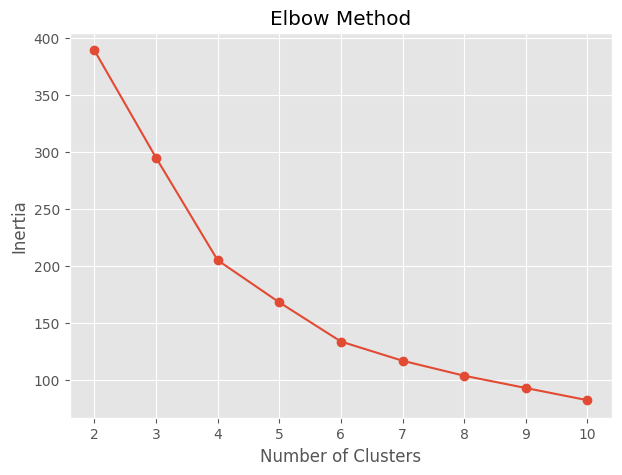

In [63]:
inertia = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

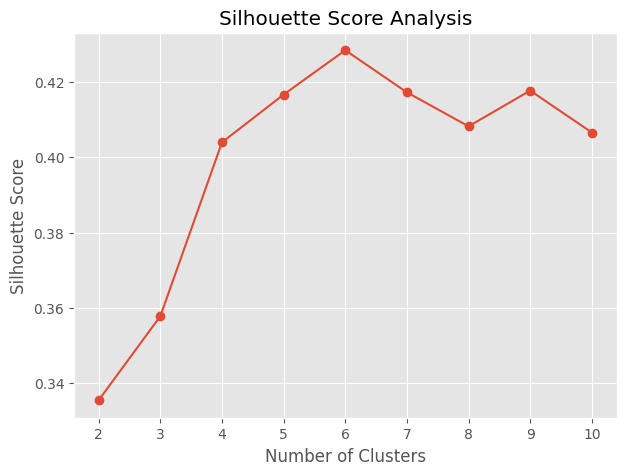

Best K: 6


In [64]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)

    scores.append(score)

plt.figure(figsize=(7,5))

plt.plot(range(2,11), scores, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score Analysis")

plt.show()

best_k = range(2,11)[np.argmax(scores)]

print("Best K:", best_k)

In [65]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


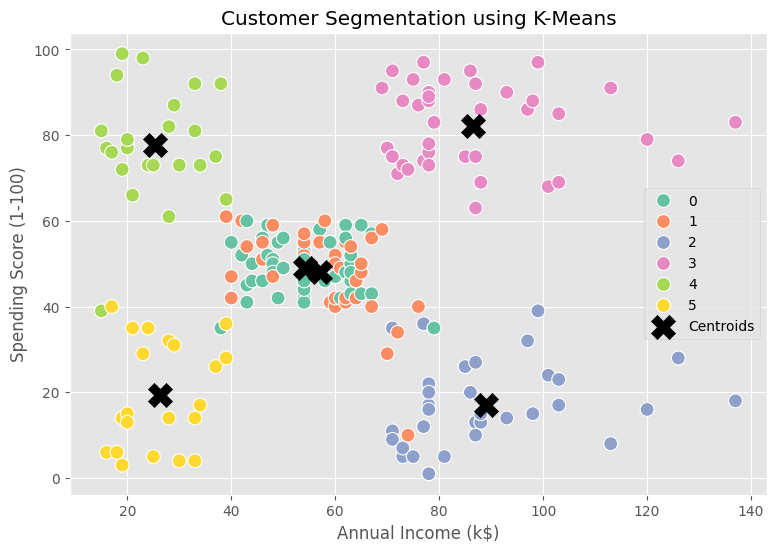

In [66]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.scatter(
    centroids[:,1],
    centroids[:,2],
    color="black",
    marker="X",
    s=300,
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

In [67]:
cluster_summary = (
    df
    .groupby("Cluster")
    .agg({
        "Age":"mean",
        "Annual Income (k$)":"mean",
        "Spending Score (1-100)":"mean",
        "CustomerID":"count"
    })
    .rename(columns={
        "CustomerID":"Customers"
    })
)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Customers
Cluster,,,,
0,56.33,54.27,49.07,45
1,26.79,57.10,48.13,39
2,41.94,88.94,16.97,33
3,32.69,86.54,82.13,39
4,25.00,25.26,77.61,23
5,45.52,26.29,19.38,21


In [68]:
silhouette = silhouette_score(
    scaled_features,
    df["Cluster"]
)

print("Inertia :", round(kmeans.inertia_,2))

print("Silhouette Score :", round(silhouette,3))

print("\nCluster Sizes\n")

print(df["Cluster"].value_counts().sort_index())

Inertia : 133.87
Silhouette Score : 0.428

Cluster Sizes

Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


In [69]:
for cluster in sorted(df["Cluster"].unique()):

    data = df[df["Cluster"] == cluster]

    print(f"\nCluster {cluster}")

    print("-" * 40)

    print(f"Customers        : {len(data)}")

    print(f"Average Age      : {data['Age'].mean():.2f}")

    print(f"Average Income   : {data['Annual Income (k$)'].mean():.2f}")

    print(f"Average Spending : {data['Spending Score (1-100)'].mean():.2f}")


Cluster 0
----------------------------------------
Customers        : 45
Average Age      : 56.33
Average Income   : 54.27
Average Spending : 49.07

Cluster 1
----------------------------------------
Customers        : 39
Average Age      : 26.79
Average Income   : 57.10
Average Spending : 48.13

Cluster 2
----------------------------------------
Customers        : 33
Average Age      : 41.94
Average Income   : 88.94
Average Spending : 16.97

Cluster 3
----------------------------------------
Customers        : 39
Average Age      : 32.69
Average Income   : 86.54
Average Spending : 82.13

Cluster 4
----------------------------------------
Customers        : 23
Average Age      : 25.00
Average Income   : 25.26
Average Spending : 77.61

Cluster 5
----------------------------------------
Customers        : 21
Average Age      : 45.52
Average Income   : 26.29
Average Spending : 19.38


In [70]:
print("""
Project Summary
---------------

• Customer segmentation was successfully performed using K-Means clustering.

• The Elbow Method suggested that five clusters provide a suitable balance between simplicity and clustering performance.

• Silhouette Score was used to evaluate cluster quality.

• The resulting customer groups exhibit distinct spending and income patterns.

• These insights can support targeted marketing, personalized promotions, and improved customer relationship management.
""")


Project Summary
---------------

• Customer segmentation was successfully performed using K-Means clustering.

• The Elbow Method suggested that five clusters provide a suitable balance between simplicity and clustering performance.

• Silhouette Score was used to evaluate cluster quality.

• The resulting customer groups exhibit distinct spending and income patterns.

• These insights can support targeted marketing, personalized promotions, and improved customer relationship management.

